# Altimetry time series for Duck

## Paths and settings

In [1]:
# paths jupyter utwente
path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/output/'

local reference systems:  
https://spatialreference.org/explorer.html?latlng=36.168923,-75.751076&ignoreWorld=true&allowDeprecated=false&authorities=EPSG&activeTypes=PROJECTED_CRS  
https://spatialreference.org/ref/epsg/2264/  
https://spatialreference.org/ref/epsg/32618/  

In [2]:
epsg_in = 4326
epsg_out = 32618 # 32618 2264 local system only required for binning altimetry points into cells
overwrite = True # True: overwrite existing files, False: do not overwrite

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import os
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats
import geojson
from shapely import Polygon

import geopandas as gpd
from coastal_data import CD_statistics
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
    
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.feature import LAND

from coastal_data import CD_helper_functions, CD_altimetry, CD_data_preparation

import pdb

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Data

### IB correction

In [6]:
fn = 'ib_correction_era5.nc'
if (not os.path.isfile(path_input_general+fn)):
    corr = CD_altimetry.compute_ib_corr(path_input_general)

ibcorr = xr.open_dataset(path_input_general + fn, engine='netcdf4')

Text(0.5, 1.0, 'IB correction in [m]')

<Figure size 2000x1000 with 0 Axes>

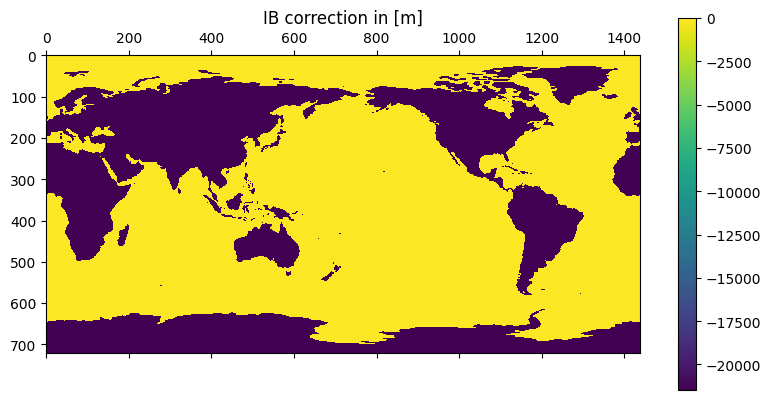

In [7]:
plt.figure(1, figsize=(20,10))
plt.matshow(ibcorr.mean('time').IB_correction)
plt.colorbar()
plt.title('IB correction in [m]')

### PSMSL Tide gauge

In [8]:
fn = 'psmsl_monthly_RLR_DUCK.txt'
tg_psmsl_orig = pd.read_csv(f'{path_input}/{fn}', sep=';', header=None, names=['date', 'SSH_RLR[mm]'])

tg_psmsl = pd.DataFrame()
tg_psmsl['date'] = CD_helper_functions.decimal_numbers_to_datetime(tg_psmsl_orig['date'])
tg_psmsl = tg_psmsl.set_index('date')

tg_psmsl['SSH_RLR[m]'] = tg_psmsl_orig['SSH_RLR[mm]'].values / 1000 - 6.993
# if absolute ssh needed, convert RLR to benchmark: https://psmsl.org/data/obtaining/rlr.diagrams/1636.php

# reduce to altimetry time period
tg_psmsl = tg_psmsl.iloc[np.nonzero(tg_psmsl.index.year >= 1992)[0]]

# remove 9999.0
idx, = np.where(tg_psmsl['SSH_RLR[m]'] < 10)
tg_psmsl = tg_psmsl.iloc[idx]

In [9]:
# IB correction
psmsl_lat = 36.183
psmsl_lon = 360 - 75.747 # from -180/180 to 0/360 degree

psmsl_ibcorr = ibcorr.interp(lat=psmsl_lat, lon=psmsl_lon, method="linear")
time_ib = pd.to_datetime(psmsl_ibcorr.time, utc=True)
values_ib = psmsl_ibcorr.IB_correction

time_psmsl = tg_psmsl.index

ib_at_psmsl_times = np.interp(time_psmsl, time_ib, values_ib)

tg_psmsl['corr_ib[m]'] = ib_at_psmsl_times

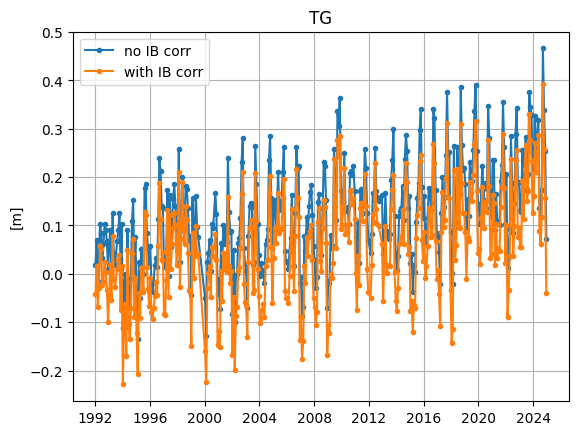

In [10]:
fig, ax = plt.subplots()
ax.plot(tg_psmsl.index, tg_psmsl['SSH_RLR[m]'], '.-', label='no IB corr')
ax.plot(tg_psmsl.index, tg_psmsl['SSH_RLR[m]']-tg_psmsl['corr_ib[m]'], '.-', label='with IB corr')
ax.set_title('TG')
ax.set_ylabel('[m]')
ax.legend()
ax.grid()

### OpenADB ALES

In [11]:
# Select which missions to use
missions = [
            'Envisat (Version 3)', # 21.06.2002 - 11.10.2010
            'Jason-1',             # 15.01.2002 - 14.01.2009
            # 'Jason-1 (EM)',      # 10.02.2009 - 02.03.2012
            # 'Jason-1 (GM)',      # 11.05.2012 - 17.06.2013
            'Jason-2',             # 12.07.2008 - 30.09.2016
            # 'Jason-2 (EM)',      # 15.10.2016 - 17.05.2017
            'Jason-3',             # 18.02.2016 - 20.04.2019
            'Saral',               # 17.03.2013 - 28.06.2016
            # 'Saral (DP)',        # 05.07.2016 - 14.04.2019
            'Sentinel-3A',         # 24.11.2017 - 04.04.2020
            'Sentinel-3B',         # 26.11.2018 - 12.04.2020
           ]

# Merge all .nc-files
fn = 'ales.nc'
if (not os.path.isfile(path_output + fn)):
    ales = CD_altimetry.combine_openadb_nc_files(path_input + '2_Duck_OpenADB')
    ales = CD_altimetry.select_missions(ales, missions)
    # Clean according to OpenADB instructions (e.g. dist to coast, std, ...)
    ales = CD_altimetry.clean_openadb_ales(ales)
    ales.to_netcdf(path_output + fn)
else:
    ales = xr.open_dataset(path_output + fn)

Cells extracted: 48 49 50 51 38 39

/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:250: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2002-06-21 15:31:49.945631024+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_min')] = pd.to_datetime(df_red.index.min())
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:251: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2020-04-12 15:33:34+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_max')] = pd.to_datetime(df_red.index.max())


cell
49.0    0.713875
30.0    0.734838
50.0    0.737103
99.0    0.740868
74.0    0.741349
77.0    0.750880
76.0    0.757715
65.0    0.794530
63.0    0.812801
64.0    0.862398
Name: R, dtype: float64
cell
110.0    0.058899
99.0     0.062778
74.0     0.064115
98.0     0.065119
73.0     0.066348
96.0     0.067152
97.0     0.071854
85.0     0.072146
61.0     0.072823
109.0    0.074071
Name: RMSE, dtype: float64
cell
102.0    0.0975
100.0    0.1455
90.0     0.3116
79.0     0.6742
112.0    1.3604
113.0    1.4022
89.0     1.9795
111.0    2.2381
101.0    2.3622
28.0     2.4546
Name: trend_diff, dtype: float64


KeyboardInterrupt: Interrupted by user

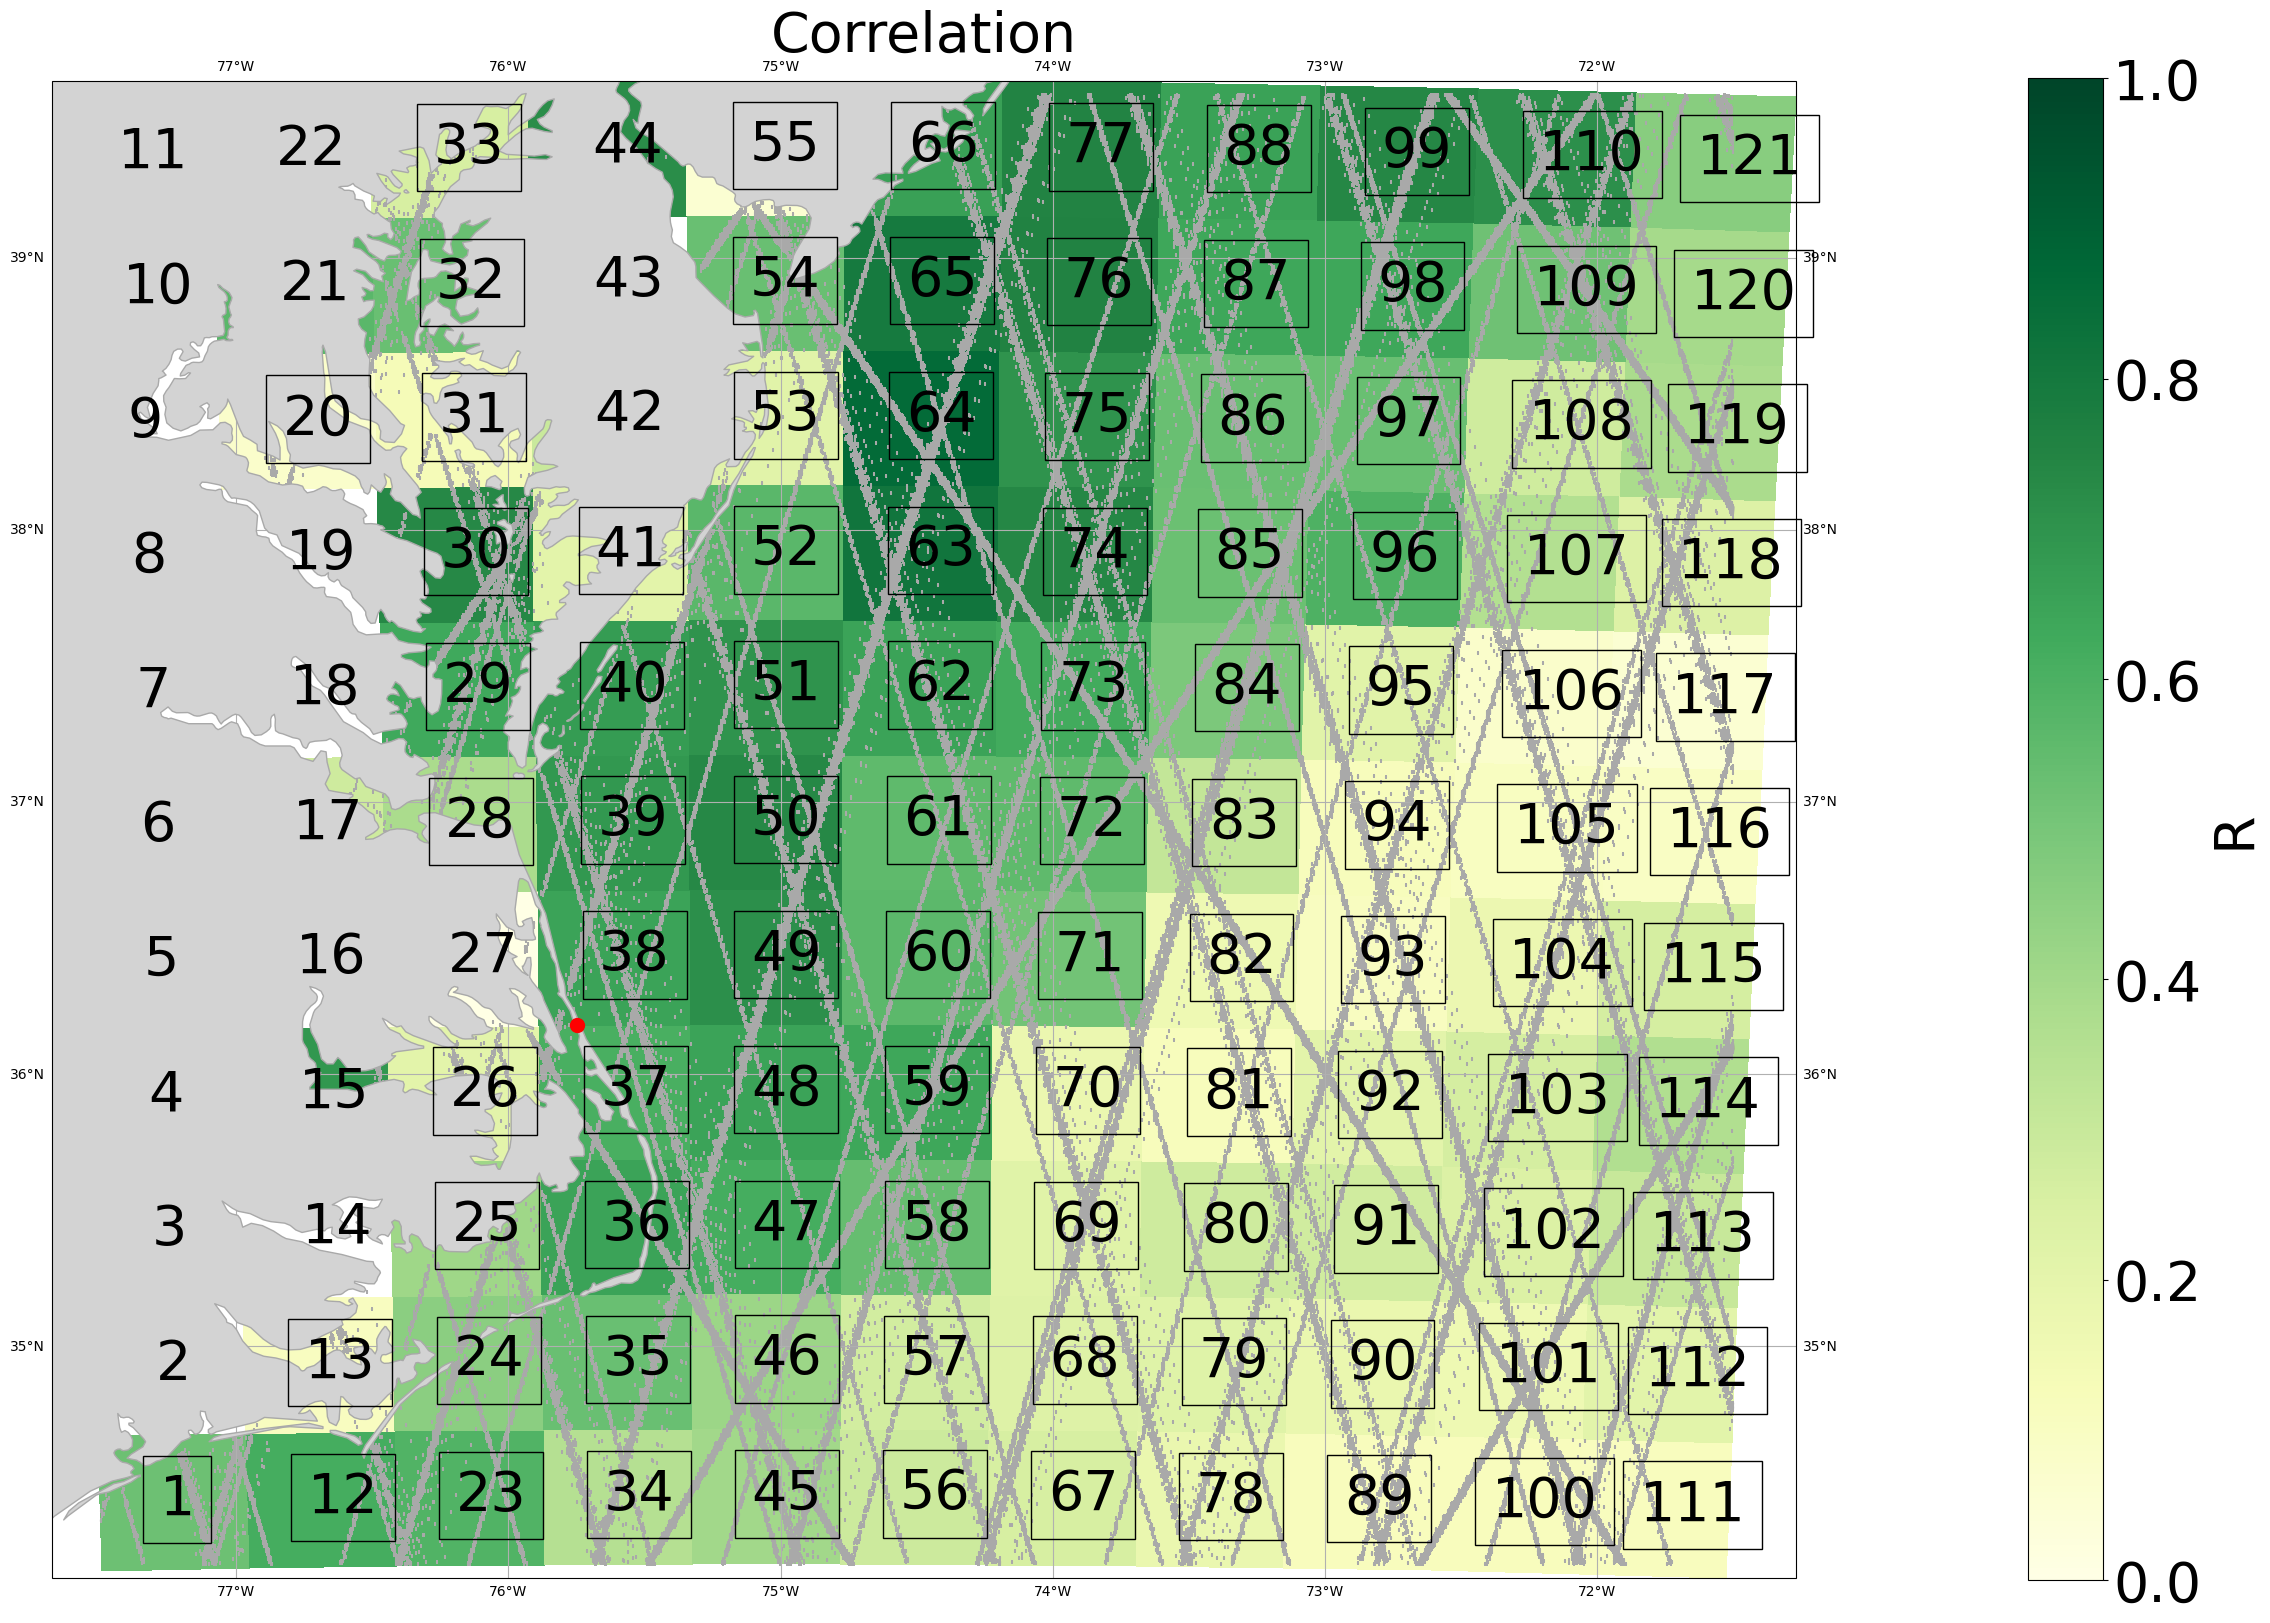

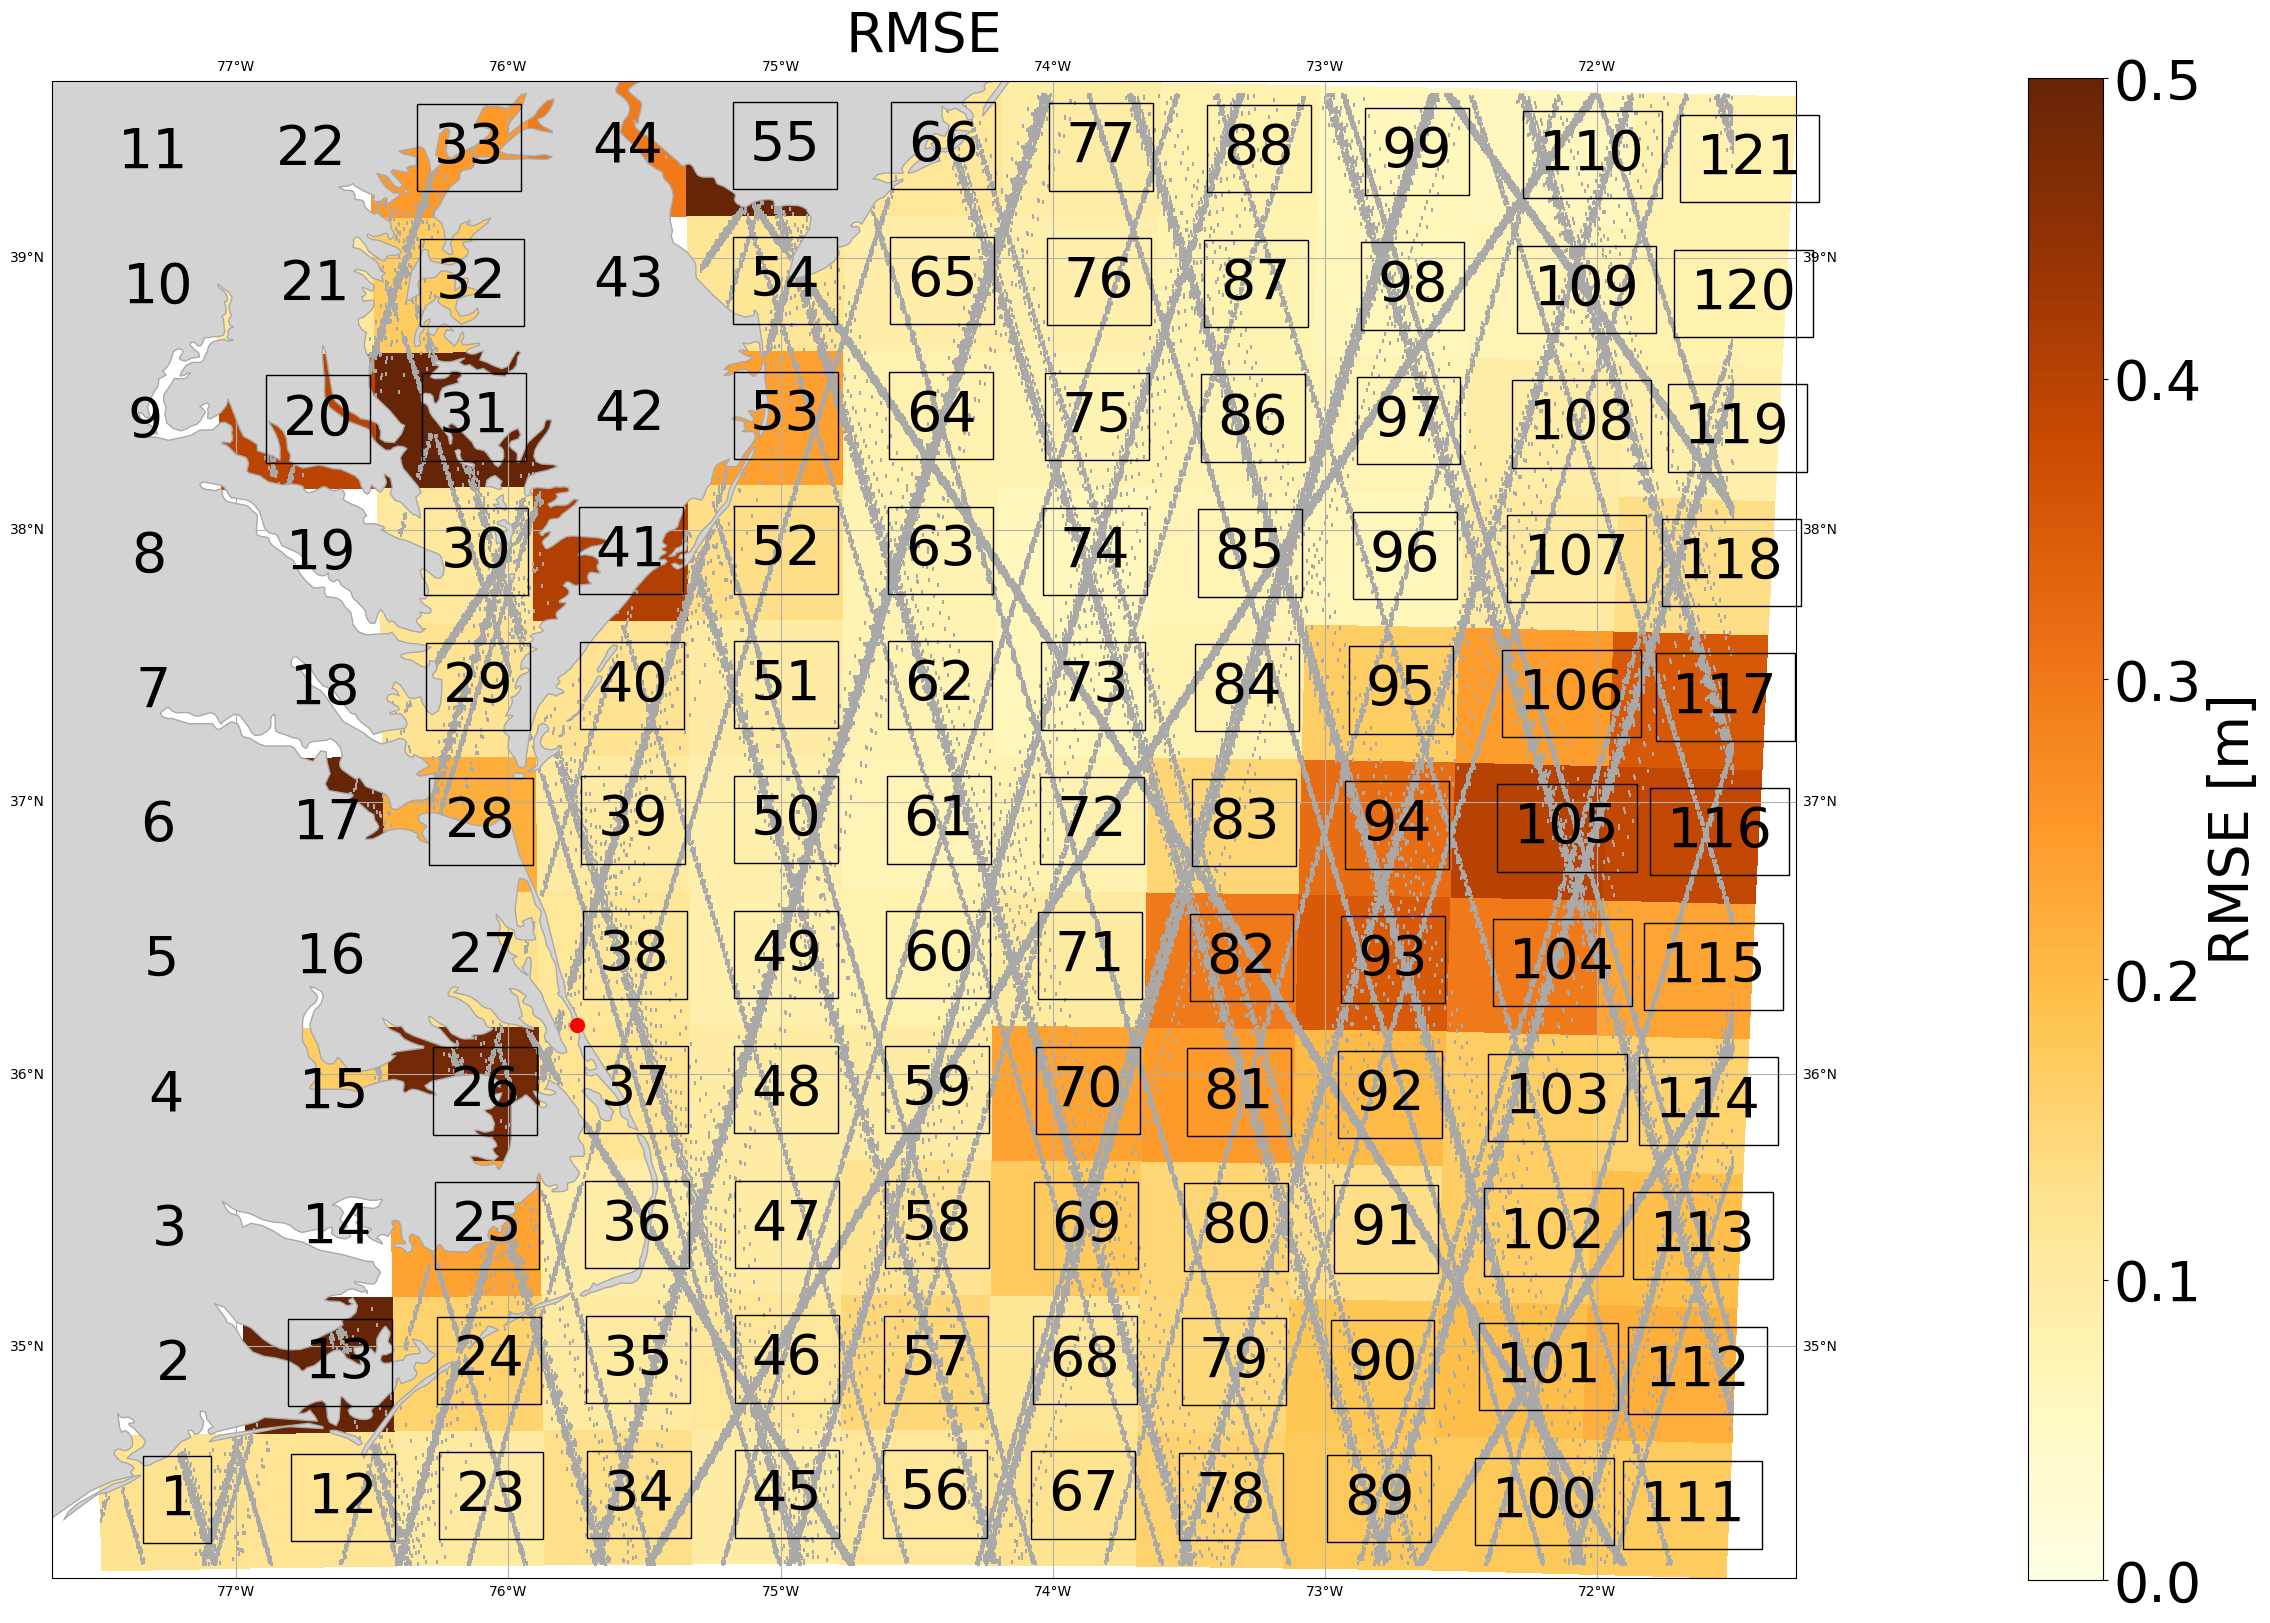

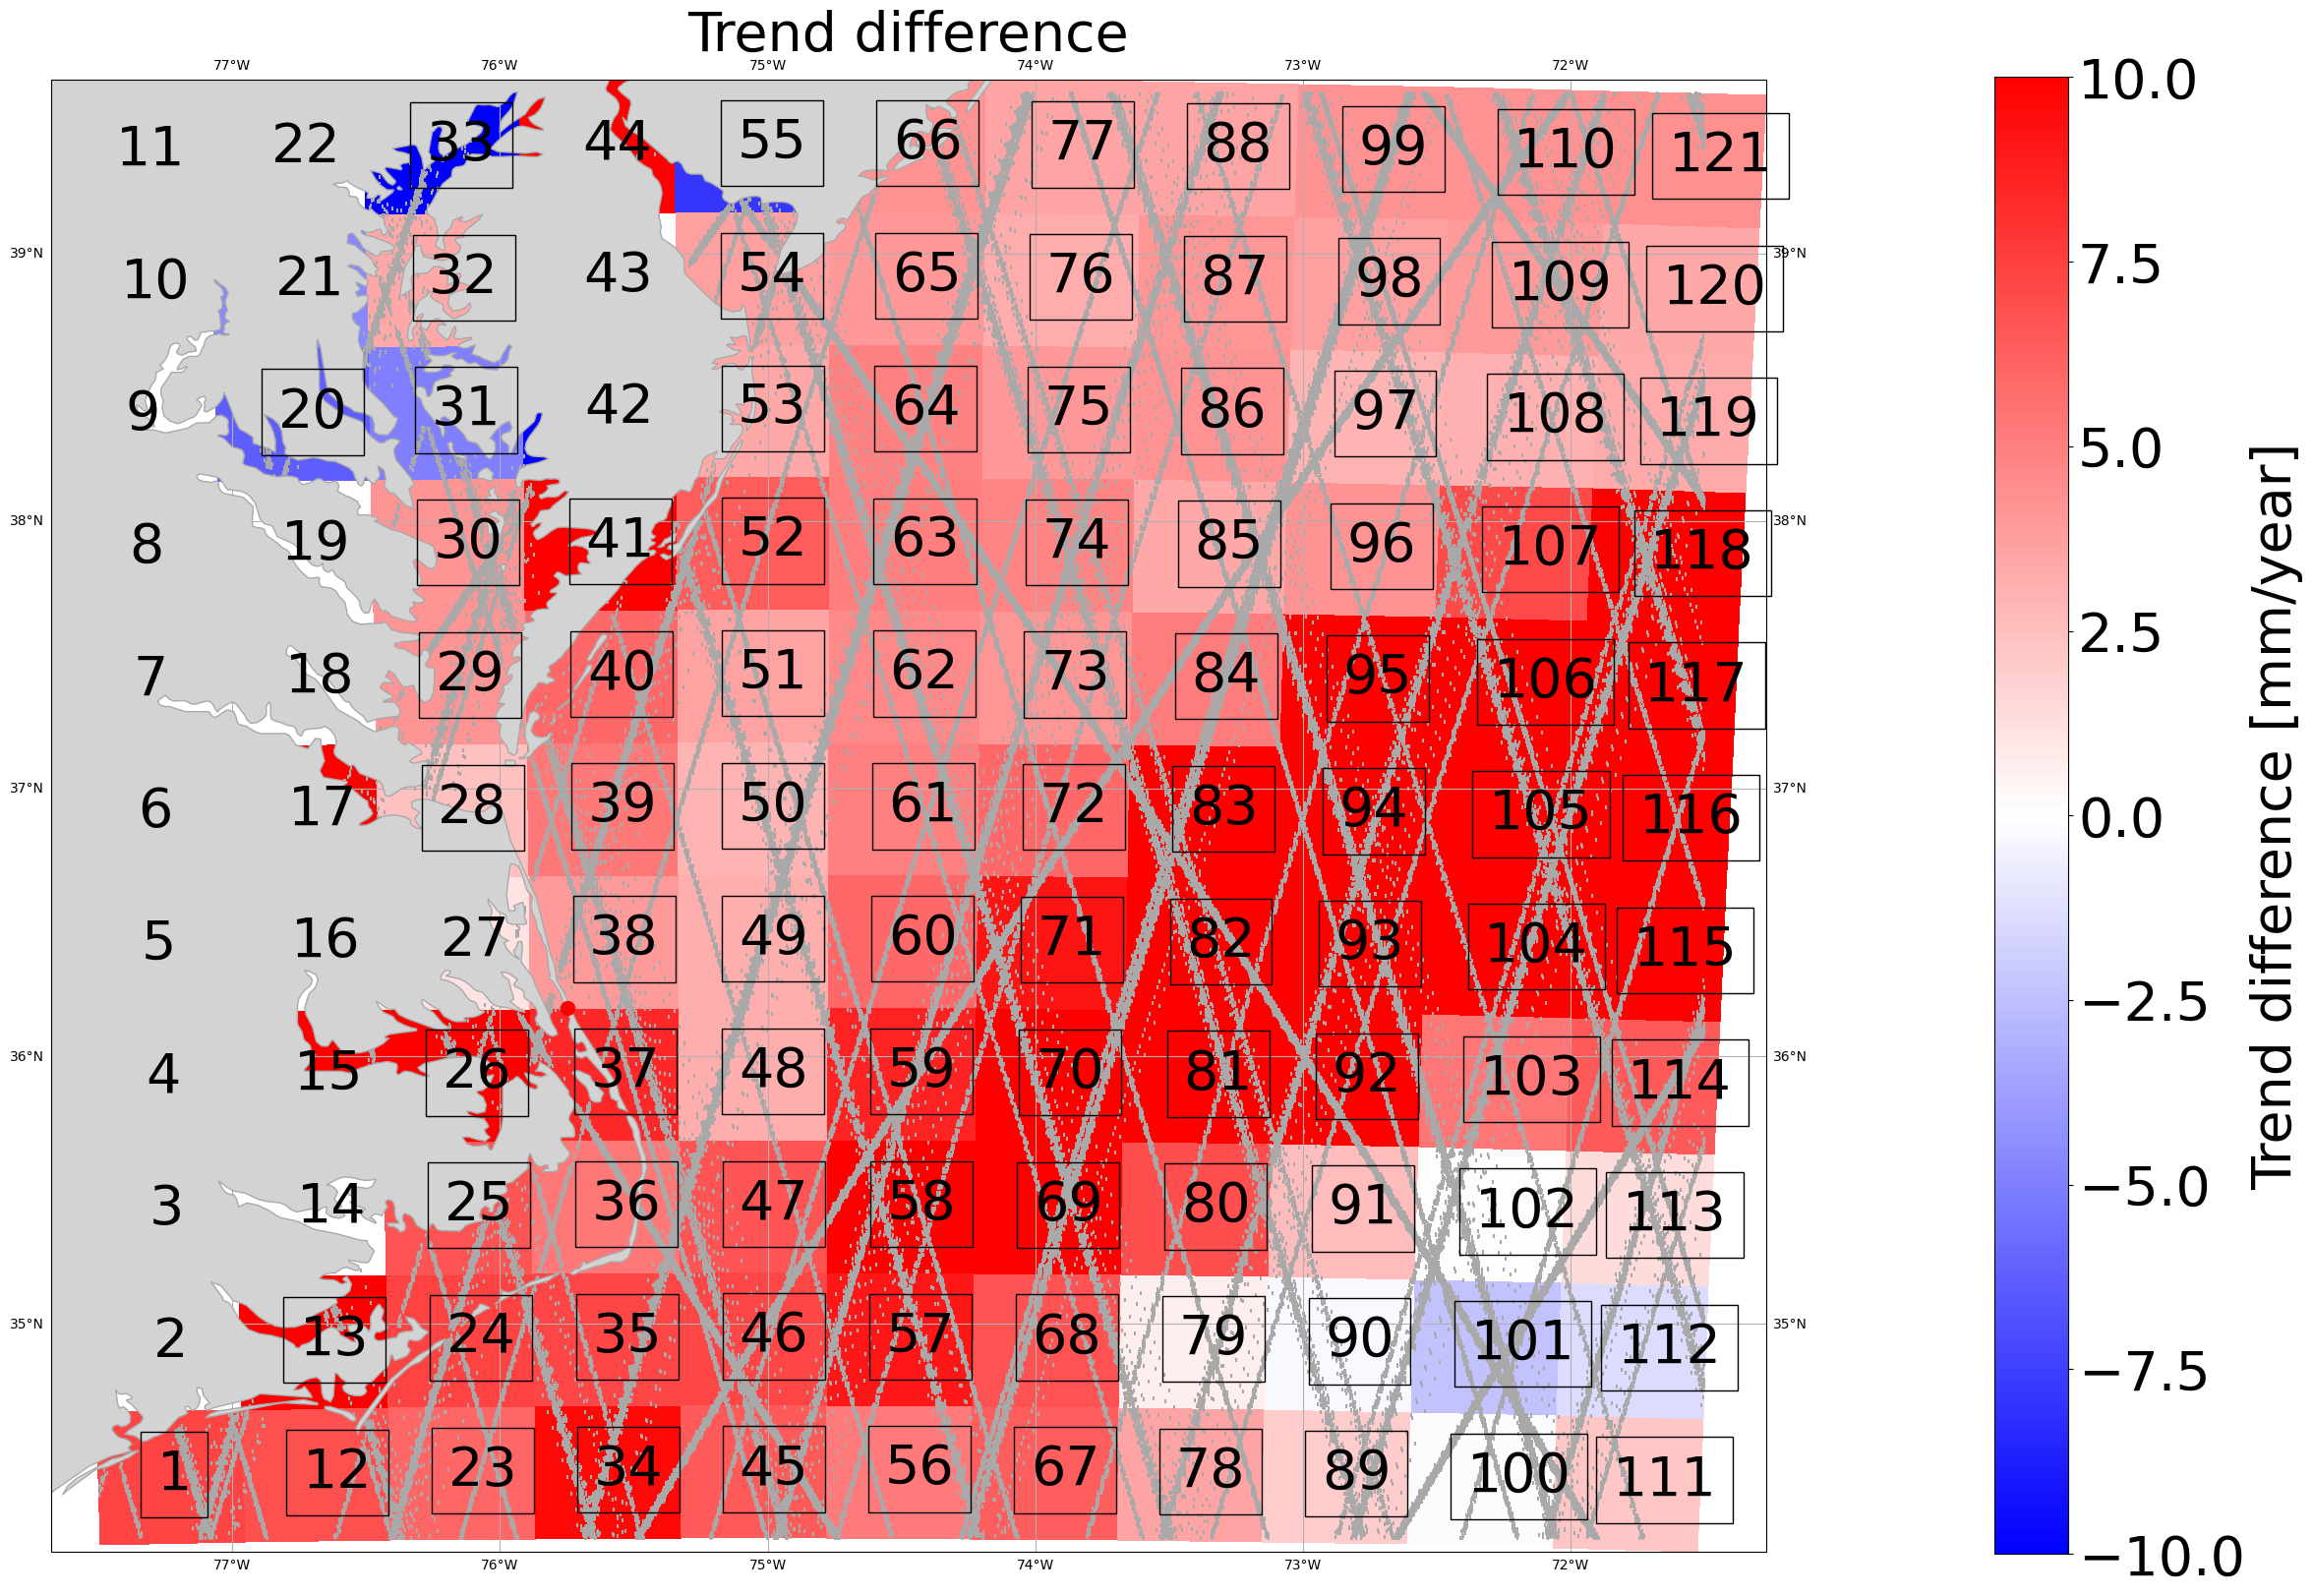

In [12]:
# Make/load timeseries
fn = f'ales_ts_epgs{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'glon', 'lat':'glat', 'sla':None, 'ssh':'ssh', 'mssh':'mssh'}
    
    tg = tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'2003-01-01', 'max':'2020-01-01'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    %matplotlib inline
    ales_ts = CD_altimetry.get_altimetry_timeseries_with_TG(ales, labels, epsg_in, epsg_out, tg, psmsl_lon, psmsl_lat, gridsize, period_covered, freq_average)
    ales_ts.to_csv(path_output+fn)
else:
    ales_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

In [ ]:
ales_ts

### RADS T/P

In [14]:
path_tp = f'{path_input}1_marge_topexA_Duck/'
tx_152 = xr.open_dataset(path_tp+'rads2nc_pass152.nc')
tx_167 = xr.open_dataset(path_tp+'rads2nc_pass167.nc')
tx_228 = xr.open_dataset(path_tp+'rads2nc_pass228.nc')
tx_243 = xr.open_dataset(path_tp+'rads2nc_pass243.nc')

tx_combined = xr.merge([tx_152, tx_167, tx_228, tx_243])
tx = CD_altimetry.clean_rads(tx_combined, 'ssha')

cells extraced (same area as for ALES extracted): 38 39 40 41 27 28

In [ ]:
# Make/load timeseries
fn = f'tx_ts_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'lon', 'lat':'lat', 'sla':'ssha', 'ssh':None, 'mssh':'mss_dtu15'}
    
    tg = tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'1993-01-31', 'max':'2002-03-31'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    # %matplotlib qt5
    tx_ts = CD_altimetry.get_altimetry_timeseries_with_TG(tx, labels, epsg_in, epsg_out, tg, psmsl_lon, psmsl_lat, gridsize, period_covered, freq_average)
    tx_ts.to_csv(path_output+fn)
else:
    tx_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:250: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2002-09-19 16:06:10.584102976+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_min')] = pd.to_datetime(df_red.index.min())
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:251: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2005-09-24 07:22:27.641670016+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_max')] = pd.to_datetime(df_red.index.max())


cell
75.0    0.482577
86.0    0.485819
24.0    0.491324
88.0    0.499328
87.0    0.534306
25.0    0.536948
63.0    0.563811
99.0    0.565756
52.0    0.669111
53.0    0.695393
Name: R, dtype: float64
cell
99.0    0.054854
88.0    0.056640
87.0    0.062786
52.0    0.064187
63.0    0.064856
62.0    0.068092
53.0    0.069170
86.0    0.072206
49.0    0.074455
24.0    0.076095
Name: RMSE, dtype: float64
cell
25.0    0.0626
53.0    0.4370
52.0    0.4475
24.0    0.6194
36.0    1.0470
35.0    1.0607
71.0    1.0748
47.0    1.1458
62.0    1.2563
63.0    1.8070
Name: trend_diff, dtype: float64


In [ ]:
tx_ts

## Remove bias between OpenADB and RADS timeseries

In [ ]:
tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts['sla_temp_av'], ales_ts['sla_temp_av'])

In [ ]:
combined = pd.concat([tx_biased_to_ales, ales_ts['sla_temp_av']])

### Compare result against tide gauge

In [ ]:
alt_mean = np.nanmean(combined.values)
tg = (tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]'])/100
tg_mean = np.nanmean(tg)
bias = tg_mean - alt_mean
tg_debias = tg - bias

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG')
ax.plot(combined.index, combined.values, '.-', label='altimetry')
ax.grid()
ax.legend()

In [ ]:
tg_at_alt_time = CD_altimetry.interpolate_tg_to_alt(combined.index, tg_debias.index, tg_debias)

corr, p = stats.pearsonr(combined, tg_at_alt_time)
print(f'corr: {round(corr,4)}, p-value: {p}')

rmse = CD_altimetry.compute_RMSE(combined, tg_at_alt_time)
print(f'RMSE: {rmse}')

x = CD_helper_functions.datetime_to_decimal_numbers(tg_at_alt_time.index)
trend_tg = CD_statistics.compute_trend(x, tg_at_alt_time)
print(f'Trend from tide gauge: {trend_tg*1000} mm/year')

x = CD_helper_functions.datetime_to_decimal_numbers(combined.index)
trend_alt = CD_statistics.compute_trend(x, combined)
print(f'Trend from altimetry: {trend_alt*1000} mm/year')

==========================================================================================  
The following parts are only for testing other techniques to extract an altimetry time series.  
\========================================================================================== 

## Extract time series from polygon

In [ ]:
path = '/home/jovyan/data/9_masks/'
fn = 'altimetry_duck_epsg32618.geojson'
with open(path+fn) as f:
    poly_duck = geojson.load(f)

duck_poly = Polygon(poly_duck['features'][0]['geometry']['coordinates'][0])

In [ ]:
ales_ts_poly = CD_altimetry.get_altimetry_timeseries_from_polygon(ales['ssh']-ales['mssh'], ales['glon'], ales['glat'], ales['time'],
                                                                  epsg_in, epsg_out, duck_poly, freq_average='ME')

tx_ts_poly = CD_altimetry.get_altimetry_timeseries_from_polygon(tx['ssha'], tx['lon'], tx['lat'], tx['time'], epsg_in, epsg_out, duck_poly, freq_average='ME')

tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts_poly['sla'], ales_ts_poly['sla'])

combined_poly = pd.concat([tx_biased_to_ales, ales_ts_poly['sla']])
combined_poly = combined_poly.dropna()

### Compare result against tide gauge

In [ ]:
alt_mean = np.nanmean(combined_poly.values)
tg = (tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]'])/100
tg_mean = np.nanmean(tg)
bias = tg_mean - alt_mean
tg_debias = tg - bias

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG')
ax.plot(combined_poly.index, combined_poly.values, '.-', label='altimetry')
# ax.plot(combined.index, combined.values, '.-', label='better fit altimetry')
ax.grid()
ax.legend()

In [ ]:
tg_at_alt_time = CD_altimetry.interpolate_tg_to_alt(combined_poly.index, tg_debias.index, tg_debias)

corr, p = stats.pearsonr(combined_poly, tg_at_alt_time)
print(f'corr: {round(corr,4)}, p-value: {p}')

rmse = CD_altimetry.compute_RMSE(combined_poly, tg_at_alt_time)
print(f'RMSE: {rmse}')

x = CD_helper_functions.datetime_to_decimal_numbers(tg_at_alt_time.index)
trend_tg = CD_statistics.compute_trend(x, tg_at_alt_time)
print(f'Trend from tide gauge: {trend_tg*1000} mm/year')

x = CD_helper_functions.datetime_to_decimal_numbers(combined_poly.index)
trend_alt = CD_statistics.compute_trend(x, combined_poly)
print(f'Trend from altimetry: {trend_alt*1000} mm/year')

## Weigh cells according to correlation and trend
Including trend does not make much sense without considering VLM

### Extract time series from single cells

In [ ]:
# Cells to extract
# ALES
c1 = np.linspace(38,40,3, dtype='int')
c2 = np.linspace(48,52,5, dtype='int')
c3 = np.linspace(59,63,5, dtype='int')
c4 = np.linspace(70,74,5, dtype='int')
c5 = np.linspace(81,85,5, dtype='int')
cells_to_extract_ales = np.concatenate([c1, c2, c3, c4, c5])

# Topex
c1 = [27,28,48,49,52]
c2 = np.linspace(38,41,4, dtype='int')
c3 = np.linspace(60,63,4, dtype='int')
c4 = np.linspace(71,74,4, dtype='int')
cells_to_extract_tx = np.concatenate([c1, c2, c3, c4])

alt_ex_ales = CD_altimetry.extract_single_cell(ales['ssh']-ales['mssh'], ales['glon'], ales['glat'], ales['time'], cells_to_extract_ales)
alt_ex_tx = CD_altimetry.extract_single_cell(tx['ssha'], tx['lon'], tx['lat'], tx['time'], cells_to_extract_tx)

### Get correlation for each cell

In [ ]:
tg = tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]']
corr_ales = CD_altimetry.get_correlation_per_cell(alt_ex_ales, tg)
corr_tx = CD_altimetry.get_correlation_per_cell(alt_ex_tx, tg)

### Get trend difference for each cell

In [ ]:
trend_diff_ales = CD_altimetry.get_trend_diff_per_cell(alt_ex_ales, tg)
trend_diff_tx = CD_altimetry.get_trend_diff_per_cell(alt_ex_tx, tg)

### Time series as weighted average
higher correlation -> higher weight -> no inverse  
higher trend difference -> smaller weight -> inverse  
sum of all weights = 1  
some cell-columns in alt_ex ar empty. No difference if weight is normed only over the non-nan values.   

In [ ]:
ales_ts = CD_altimetry.timeseries_as_weighted_average(alt_ex_ales, corr_ales, trend_diff_ales, w_corr=.5)
tx_ts = CD_altimetry.timeseries_as_weighted_average(alt_ex_tx, corr_tx, trend_diff_tx, w_corr=.5)

### Combined topex and ales

In [ ]:
tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts['sla'], ales_ts['sla'])

combined_corr = pd.concat([tx_biased_to_ales, ales_ts['sla']])
combined_corr = combined_corr.dropna()

### Compare result against tide gauge

In [ ]:
alt_mean = np.nanmean(combined_corr.values)
tg_mean = np.nanmean(tg)
bias = tg_mean - alt_mean
tg_debias = tg - bias

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG')
ax.plot(combined_corr.index, combined_corr.values, '.-', label='altimetry')
ax.grid()
ax.legend()

In [ ]:
diff = combined_poly - combined_corr
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG', c='darkgrey')
# ax.plot(diff.index, diff, '.-', label='difference')
ax.plot(combined_poly.index, combined_poly.values, '.-', label='polygon')
ax.plot(combined_corr.index, combined_corr.values, '.-', label='weighting')
ax.set_ylabel('[m]')
ax.grid()
ax.legend()

In [ ]:
tg_at_alt_time = CD_altimetry.interpolate_tg_to_alt(combined_corr.index, tg_debias.index, tg_debias)

corr, p = stats.pearsonr(combined_corr, tg_at_alt_time)
print(f'corr: {round(corr,4)}, p-value: {p}')

rmse = CD_altimetry.compute_RMSE(combined_corr, tg_at_alt_time)
print(f'RMSE: {rmse}')

x = CD_helper_functions.datetime_to_decimal_numbers(tg_at_alt_time.index)
trend_tg = CD_statistics.compute_trend(x, tg_at_alt_time)
print(f'Trend from tide gauge: {trend_tg*1000} mm/year')

x = CD_helper_functions.datetime_to_decimal_numbers(combined_corr.index)
trend_alt = CD_statistics.compute_trend(x, combined_corr)
print(f'Trend from altimetry: {trend_alt*1000} mm/year')

In [ ]:
fn = f'tp_plus_ales_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    combined_corr.to_frame().rename_axis('time').to_csv(path_output+fn)